In [181]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

 # <font color="lightblue">**Week 4 Capstone — Predicting Internship Selection Outcomes.**





In [182]:
#Extend Your Dataset With New Features

df = pd.read_csv("applicants_cleaned.csv")
np.random.seed(42)

#df["Status"] = np.random.choice(["Under Review", "Selected", "Rejected"], size=len(df), p=[0.3, 0.4, 0.3])

df["num_skills_listed"] = np.random.randint(1, 9, size=len(df))
df["has_portfolio"] = np.random.choice(["Yes", "No"], size=len(df), p=[0.4, 0.6])
df["prior_hackathon_participation"] = np.random.choice(["Yes", "No"], size=len(df), p=[0.3, 0.7])
df["statement_quality_score"] = np.random.randint(1, 11, size=len(df))

print(df["Status"].value_counts())
df.head()

Status
Selected        29
Rejected        28
Under Review     8
Name: count, dtype: int64


,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status,num_skills_listed,has_portfolio,prior_hackathon_participation,statement_quality_score
0,Bob Davis,bob.davis@example.com,1651623197,Web Development,Columbia,4/2/2021,Rejected,7,Yes,Yes,6
1,Bob Brown,bob.brown@example.com,1898471390,Data Science,Harvard University,7/10/2020,Rejected,4,No,No,1
2,Eva Davis,eva.davis@example.com,3476490784,Cybersecurity,Yale,11/27/2021,Under Review,5,No,Yes,9
3,Frank Williams,frank.williams@example.com,1586734256,Cloud Computing,Cambridge,1/5/2022,Selected,7,Yes,No,6
4,Alice Garcia,alice.garcia@example.com,5409003485,Web Development,Cambridge,6/10/2020,Rejected,3,Yes,No,3


<font color="pink"> The four newly added features (num_skills_listed, has_portfolio, prior_hackathon_participation, and statement_quality_score) are simulated features, not real historical data. In a real NextGenLearners deployment, this data would need to be actually collected from applications (e.g., a required skills field, a portfolio URL field) before this model could be trusted with real decisions. Say this clearly — pretending simulated data is real would be misleading.

In [183]:
#Feature Preparation — Getting Data Ready for a Model

df['has_portfolio'] = df['has_portfolio'].map({'Yes': 1, 'No': 0})
df['prior_hackathon_participation'] = df['prior_hackathon_participation'].map({'Yes': 1, 'No': 0})
# Convert your target column (what you're predicting) to 0/1
#df_model = df[df['Status'] != 'Under Review'].copy()
df['target'] = df['Status'].apply(lambda x: 1 if x == 'Selected' else 0)
df_model = df[df['Status'] != 'Under Review'].copy()

print("All data:")
print(df["Status"].value_counts())

print("\nModel data:")
print(df_model["Status"].value_counts())

print("\nTarget:")
print(df_model["target"].value_counts())
print(df_model["Status"].value_counts())
print(df_model["target"].value_counts())

# One-hot encode the Domain column
df_model = pd.get_dummies(df_model, columns=['Domain Applied'], drop_first=True)
# Select your final feature set
feature_columns = ['num_skills_listed', 'has_portfolio', 'prior_hackathon_participation',
                   'statement_quality_score'] + [col for col in df_model.columns
                                                 if col.startswith('Domain Applied_')]
X = df_model[feature_columns]
y = df_model['target']

All data:
Status
Selected        29
Rejected        28
Under Review     8
Name: count, dtype: int64

Model data:
Status
Selected    29
Rejected    28
Name: count, dtype: int64

Target:
target
1    29
0    28
Name: count, dtype: int64
Status
Selected    29
Rejected    28
Name: count, dtype: int64
target
1    29
0    28
Name: count, dtype: int64


In [184]:
#  Select your final feature set
feature_columns = ['num_skills_listed', 'has_portfolio', 'prior_hackathon_participation',
                   'statement_quality_score'] + [col for col in df_model.columns
                                                 if col.startswith('Domain Applied_')]
X = df_model[feature_columns]
y = df_model['target']

### Final Feature Set

The model uses four simulated applicant features and the one-hot encoded application domain:

* **num_skills_listed** — the number of relevant skills listed by the applicant.
* **has_portfolio** — whether the applicant provided a portfolio or GitHub link.
* **prior_hackathon_participation** — whether the applicant had participated in a hackathon previously.
* **statement_quality_score** — a simulated score representing the quality of the applicant's short statement.
* **Domain Applied** — converted into separate numerical columns using one-hot encoding.

Applicant Name, Email, Phone, University, and Application Date were excluded from the predictive features. Names, email addresses, and phone numbers are identifiers rather than meaningful predictive signals. They are also inappropriate to use as model features. Other information was excluded because the assignment's specified feature set focuses on the four new applicant features and application domain.

The four new applicant features are simulated for this exercise and do not represent real historical applicant behavior.


In [185]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(len(X_train))
print(len(X_test))


45
12


### Train/Test Split

The dataset was divided into training and test sets using an 80/20 split. After removing applicants whose status was Under Review, 57 applicants had confirmed outcomes: 29 were Selected and 28 were Rejected.

The split resulted in 45 applicants in the training set and 12 applicants in the test set.

The training data was used to teach the model patterns in the applicant features, while the test data was kept separate to evaluate how well the model could predict outcomes for unseen applicants.

Because the test set contains only 12 applicants, the evaluation results should be interpreted cautiously. A small test set means that a few individual predictions can noticeably change the reported accuracy, precision, and recall.


In [186]:
#Train the Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [187]:
#Make predictions on the test set
y_pred = model.predict(X_test)

In [188]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 83.33%


### Model Evaluation — Accuracy

The Logistic Regression model achieved an **accuracy of 83.33%** on the test set.

This means that the model correctly predicted the selection outcome for **10 out of the 12 applicants** in the test set.

Accuracy represents the percentage of test-set applicants whose outcomes were correctly classified as Selected or Not Selected.

However, the test set contains only 12 applicants, so this accuracy should not be interpreted as a reliable estimate of how the model would perform on a much larger group of applicants. The result is useful for demonstrating the modeling process, but additional real-world data would be needed for stronger evaluation.

Precision: 83.33%
Recall: 83.33%


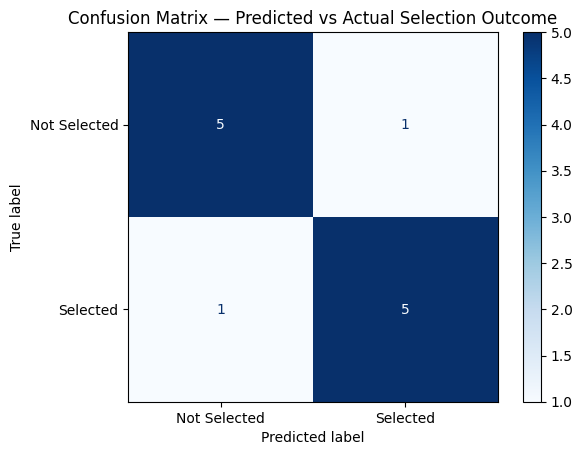

In [189]:
#Precision, Recall, and/or Confusion Matrix
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Selected', 'Selected'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Predicted vs Actual Selection Outcome')
plt.show()

### Precision and Recall

The model achieved 83.33% precision and 83.33% recall on the test set.

Precision: Of the applicants that the model predicted would be Selected, 83.33% were actually Selected. A higher precision means fewer applicants were incorrectly predicted as Selected.

Recall: Of the applicants who were actually Selected, the model correctly identified 83.33% of them. A higher recall means fewer genuinely selected applicants were missed by the model.

Because these values are calculated from only 12 test applicants, they should be interpreted cautiously.

In [190]:
#Interpret — Which Features Mattered Most?
coefficients = pd.DataFrame({'Feature': X.columns,'Coefficient': model.coef_[0] }).sort_values(by='Coefficient', ascending=False)
print(coefficients)

                           Feature  Coefficient
2    prior_hackathon_participation     0.784221
0                num_skills_listed     0.203031
3          statement_quality_score     0.091588
7   Domain Applied_Web Development     0.075912
5      Domain Applied_Data Science    -0.227015
4     Domain Applied_Cybersecurity    -0.246276
6  Domain Applied_Machine Learning    -0.369385
1                    has_portfolio    -0.641133


### Which Features Mattered Most?

The Logistic Regression coefficients show how the model associated each feature with the predicted Selected outcome.

In this dataset, **prior_hackathon_participation** had the largest positive coefficient, meaning that the model associated this feature with a higher likelihood of being predicted as Selected. **num_skills_listed** and **statement_quality_score** also had positive coefficients.

On the other hand, **has_portfolio** had a negative coefficient in this particular model, while several domain categories also had negative coefficients relative to the reference domain.

These results describe patterns learned by the model from this particular dataset. They should not be interpreted as evidence that these factors actually cause internship selection. In particular, several of the features were simulated for this exercise, so these findings would need to be validated using real historical application data.


In [191]:
#Train the Model
model =  DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [192]:
#Make predictions on the test set
y_pred = model.predict(X_test)

In [193]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 75.00%


### Decision Tree — Accuracy

The Decision Tree model achieved **75.00% accuracy** on the test set.

This means that the model correctly predicted the selection outcome for **9 out of the 12 applicants** in the test set.

Although this provides an indication of the model's performance on unseen data, the test set is small. Therefore, the accuracy should be interpreted cautiously rather than treated as a reliable estimate of performance on future applicants.


Precision: 80.00%
Recall: 66.67%


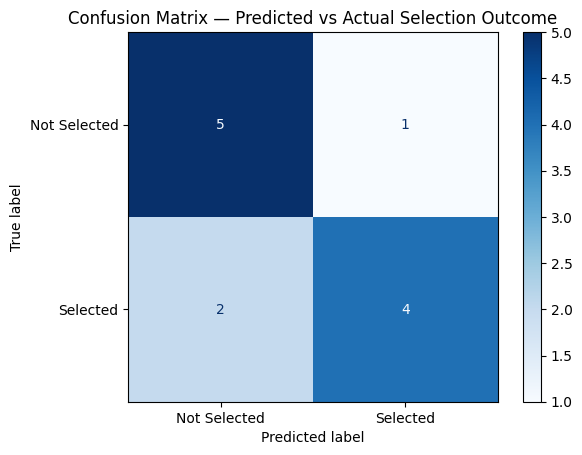

In [194]:
#Precision, Recall, and/or Confusion Matrix
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Selected', 'Selected'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Predicted vs Actual Selection Outcome')
plt.show()

### Decision Tree — Precision and Recall

The Decision Tree achieved **80.00% precision** and **66.67% recall** on the test set.

**Precision:** Of the applicants predicted to be Selected, 80.00% were actually Selected. This indicates that the model produced relatively few false positive selection predictions.

**Recall:** Of all applicants who were actually Selected, the model correctly identified 66.67% of them. This means that some applicants who were actually Selected were missed by the model.

Because these metrics are calculated using only 12 test applicants, the results should be interpreted cautiously.


                           Feature  Importance
0                num_skills_listed    0.448201
1                    has_portfolio    0.195505
3          statement_quality_score    0.179455
2    prior_hackathon_participation    0.176839
4     Domain Applied_Cybersecurity    0.000000
5      Domain Applied_Data Science    0.000000
6  Domain Applied_Machine Learning    0.000000
7   Domain Applied_Web Development    0.000000


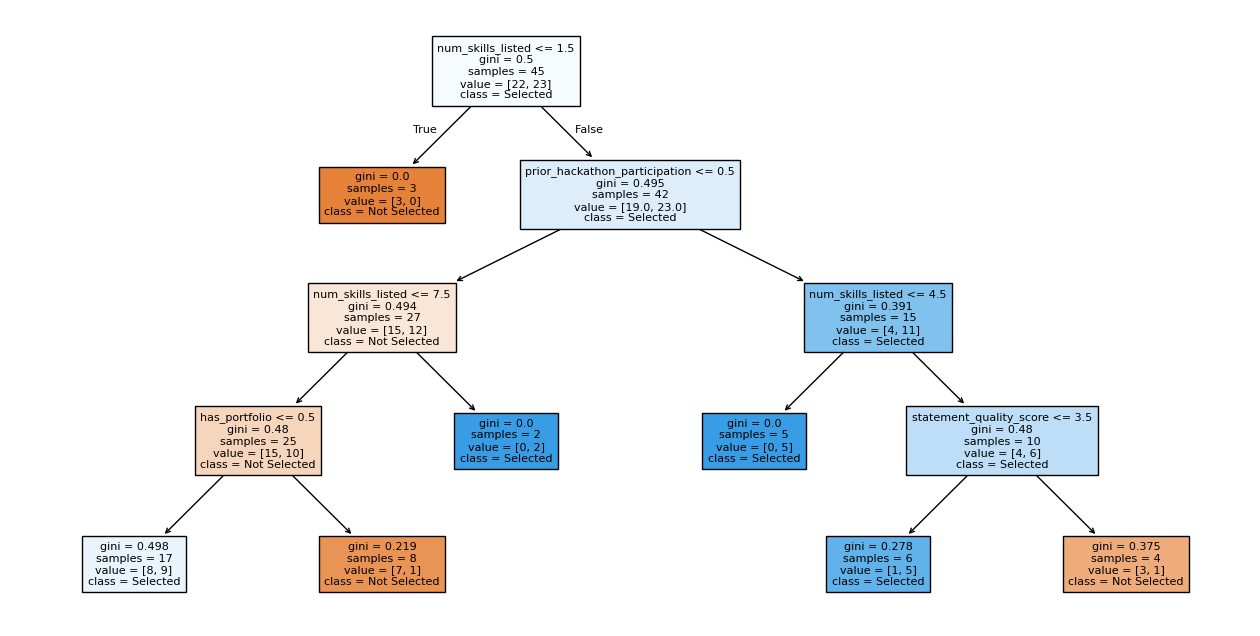

In [195]:
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_ }).sort_values(by='Importance', ascending=False)
print(importance)  # Optional: visualize the tree itself
plt.figure(figsize=(16,8))
plot_tree(model, feature_names=X.columns, class_names=['Not Selected', 'Selected'], filled=True, fontsize=8)
plt.show()

### Which Features Mattered Most?

A Decision Tree provides feature importance values that show which input features contributed most to the tree's decisions.

A higher importance value means that the feature played a larger role in separating **Selected** applicants from **Not Selected** applicants in this dataset.

The feature importance results should be interpreted as patterns learned by this particular model. They do not prove that a feature causes an applicant to be selected.

Because several features were simulated for this exercise, these findings should not be presented as conclusions about the actual NextGenLearners selection process. The relationships would need to be validated using real historical application data.


## Executive Summary

**What we did:**
We built a Logistic Regression model to explore whether applicant information could be used to predict internship selection outcomes. The dataset was prepared by adding four simulated features: number of skills listed, portfolio availability, prior hackathon participation, and statement quality score. Applicants with an Under Review status were excluded because they did not have a confirmed outcome.

**What we found:**
The model achieved **83.33% accuracy, 83.33% precision, and 83.33% recall** on the test set of 12 applicants. The model's coefficients showed that prior hackathon participation had the strongest positive association with the predicted Selected outcome in this dataset. Number of skills listed and statement quality score also had positive coefficients.

**Important caveats:**
This analysis uses a small dataset, and the four additional applicant features were simulated rather than collected from real historical applications. The test set contains only 12 applicants, so the evaluation metrics can change noticeably with a different split. The results should therefore be viewed as an illustration of the machine-learning workflow rather than a production-ready measure of prediction performance. A model trained on historical selection decisions could also reproduce biases present in those decisions.

**Recommendation:**
Before using a prediction model for actual internship selection, NextGenLearners should collect these applicant features consistently from real applications and evaluate the model on a much larger historical dataset. The model should be used only as a decision-support tool and should not replace human review.
